<a href="https://colab.research.google.com/github/Konzx/Quant-Finance-Projects/blob/main/Alpha_Research_%26_Feature_Engineering_Pipeline_for_Nifty_50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing Libraries**

In [4]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings(action = 'ignore')
from pathlib import Path
import duckdb
from arch import arch_model
from xgboost import XGBRegressor
# import mplfinance as mpf

# **Reading Data**

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
spot = pd.read_parquet(r"/content/drive/Othercomputers/My Laptop/1 EPAT 2025/@ My 2025 and onwards effort/Kite_NIFTY_INDEX_2006_01_01_to_2026_01_15.parquet")
spot['date_only'] = spot['Datetime'].dt.date
spot.set_index('Datetime', inplace = True)
spot.sort_index(inplace = True)

df = spot['2023-01-01': '2025-12-31']
df.head()

,Open,High,Low,Close,date_only
Datetime,,,,,
2023-01-02 09:15:00,18131.70,18150.15,18117.55,18141.35,2023-01-02
2023-01-02 09:16:00,18142.20,18145.70,18131.40,18135.65,2023-01-02
2023-01-02 09:17:00,18133.25,18140.55,18120.65,18140.55,2023-01-02
2023-01-02 09:18:00,18139.40,18139.40,18120.15,18130.75,2023-01-02
2023-01-02 09:19:00,18130.30,18133.55,18113.05,18113.10,2023-01-02


# **Plan**

- signal generation ( 15 mins)
- Target definition (30 mins)
- feature engineering (1 hr)
- evaluating features ( 30 mins)
- If good then proceed to modelling ( 30 mins )
- evaluation and threshold calibration ( 15 mins)
- filtering the trades with good precision (15 mins)
- Go for backtesting with the same rules as target definition. (30 mins )

# **Signal generation**

In [10]:
def add_breakout_signal(df,breakout_lookback=15):
    """
    Adds breakout signals to OHLC dataframe.

    Long signal (1):
    - Bullish candle
    - High breaks recent_high

    Short signal (-1):
    - Bearish candle
    - Low breaks recent_low
    """

    df = df.copy()

    # --- Recent highs/lows excluding current candle ---
    df['recent_high'] = df['High'].rolling(breakout_lookback).max().shift(1)
    df['recent_low']  = df['Low'].rolling(breakout_lookback).min().shift(1)

    # --- Convert to NumPy arrays for speed ---
    open_ = df['Open'].to_numpy()
    close = df['Close'].to_numpy()
    high = df['High'].to_numpy()
    low = df['Low'].to_numpy()
    rh = df['recent_high'].to_numpy()
    rl = df['recent_low'].to_numpy()

    # --- Candle direction ---
    bullish = close > open_
    bearish = close < open_

    # --- Breakout conditions ---
    long_breakout = bullish & (close > rh)
    short_breakout = bearish & (close < rl)

    # --- Final signal ---
    df['signal'] = np.select(
        [long_breakout , short_breakout ],
        [1, -1],
        default=0
    ).astype(np.int8)

    return df

In [11]:
df = add_breakout_signal(df,breakout_lookback=15)
df.tail()

,Open,High,Low,Close,date_only,recent_high,recent_low,signal
Datetime,,,,,,,,
2025-12-31 15:25:00,26127.55,26131.70,26125.20,26129.35,2025-12-31,26134.90,26115.05,0
2025-12-31 15:26:00,26129.35,26131.60,26126.15,26130.35,2025-12-31,26134.90,26115.05,0
2025-12-31 15:27:00,26130.35,26132.15,26126.80,26128.40,2025-12-31,26134.90,26115.05,0
2025-12-31 15:28:00,26128.40,26136.15,26128.05,26134.40,2025-12-31,26134.90,26115.05,0
2025-12-31 15:29:00,26132.55,26141.85,26128.65,26141.85,2025-12-31,26136.15,26115.55,1


In [12]:
df_copy = df.copy()
df_copy.reset_index(inplace = True)
df1 = duckdb.query("""
select
df_copy.Datetime,
df_copy.Open,
df_copy.High,
df_copy.Low	,
df_copy.Close,
df_copy.date_only,
df_copy.recent_high	,
df_copy.recent_low,
case when alternate_signals.signal is null then 0 else alternate_signals.signal end as signal

from

df_copy

left join

    (select *
    from
    (select * , lag(signal) over (partition by date_only order by Datetime asc ) as prev_signal
    from
    (select *
    from df_copy
    where signal != 0
    order by Datetime asc)
    order by Datetime asc)
    where prev_signal != signal or prev_signal is null  order by Datetime asc) as alternate_signals

on df_copy.Datetime = alternate_signals.Datetime
""").to_df()
df1.set_index("Datetime", inplace = True)
df1.sort_index(inplace=True)
df1['signal'].value_counts()
df1.head()

,Open,High,Low,Close,date_only,recent_high,recent_low,signal
Datetime,,,,,,,,
2023-01-02 09:15:00,18131.70,18150.15,18117.55,18141.35,2023-01-02,NaN,NaN,0
2023-01-02 09:16:00,18142.20,18145.70,18131.40,18135.65,2023-01-02,NaN,NaN,0
2023-01-02 09:17:00,18133.25,18140.55,18120.65,18140.55,2023-01-02,NaN,NaN,0
2023-01-02 09:18:00,18139.40,18139.40,18120.15,18130.75,2023-01-02,NaN,NaN,0
2023-01-02 09:19:00,18130.30,18133.55,18113.05,18113.10,2023-01-02,NaN,NaN,0


In [13]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 277496 entries, 2023-01-02 09:15:00 to 2025-12-31 15:29:00
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Open         277496 non-null  float64       
 1   High         277496 non-null  float64       
 2   Low          277496 non-null  float64       
 3   Close        277496 non-null  float64       
 4   date_only    277496 non-null  datetime64[us]
 5   recent_high  277481 non-null  float64       
 6   recent_low   277481 non-null  float64       
 7   signal       277496 non-null  int8          
dtypes: datetime64[us](1), float64(6), int8(1)
memory usage: 17.2 MB


# **Creating Target**

In [14]:
def add_target(
    df,
    signal_col="signal",
    close_col="Close",
    horizon=5
):
    """
    Assumes:
    signal = +1 for long/buy
    signal = -1 for short/sell
    signal = 0 for no signal

    Creates:
    - next_xmin_net_move_pct
    - next_xmin_favorable_move_pct
    - next_xmin_efficiency_ratio
    - next_xmin_signal_score
    """

    df = df.copy()

    close = df[close_col].to_numpy()
    signal = df[signal_col].to_numpy()

    net_move_pct_arr = np.full(len(df), np.nan)
    favorable_move_pct_arr = np.full(len(df), np.nan)
    er_arr = np.full(len(df), np.nan)
    score_arr = np.full(len(df), np.nan)
    directional_er_arr = np.full(len(df), np.nan)

    for i in range(len(df)):

        sig = signal[i]

        if sig == 0:
            continue

        start = i + 1
        end = min(i + horizon + 1, len(df))

        future_close = close[start:end]

        if len(future_close) < 2:
            continue

        signal_close = close[i]

        # Path including signal close
        path = np.r_[signal_close, future_close]

        # Raw net movement over horizon
        net_move = path[-1] - path[0]

        # Direction-adjusted move
        favorable_move = sig * net_move

        # Percentage move
        net_move_pct = (net_move / signal_close) * 100
        favorable_move_pct = (favorable_move / signal_close) * 100

        # Efficiency Ratio:
        # how direct/smooth the move was
        total_path = np.sum(np.abs(np.diff(path)))

        if total_path == 0:
            er = 0
        else:
            er = abs(net_move) / total_path

        net_move_pct_arr[i] = net_move_pct
        favorable_move_pct_arr[i] = favorable_move_pct
        er_arr[i] = er

        directional_er_arr[i] = np.sign(favorable_move_pct)* er

    df[f"horizon_net_move_pct"] = net_move_pct_arr
    df[f"horizon_favorable_move_pct"] = favorable_move_pct_arr
    df[f"horizon_efficiency_ratio"] = er_arr
    df[f"horizon_directional_er"] = directional_er_arr


    return df

In [15]:
df1 = add_target(
    df1,
    signal_col="signal",
    close_col="Close",
    horizon=5
)

In [16]:
df1['signal'].value_counts()

,count
signal,
0,268714
1,4392
-1,4390


In [18]:
signal_df = df1[df1["signal"] != 0]

In [19]:
df1.head(2)

,Open,High,Low,Close,date_only,recent_high,recent_low,signal,horizon_net_move_pct,horizon_favorable_move_pct,horizon_efficiency_ratio,horizon_directional_er
Datetime,,,,,,,,,,,,
2023-01-02 09:15:00,18131.7,18150.15,18117.55,18141.35,2023-01-02,NaN,NaN,0,NaN,NaN,NaN,NaN
2023-01-02 09:16:00,18142.2,18145.70,18131.40,18135.65,2023-01-02,NaN,NaN,0,NaN,NaN,NaN,NaN


# **Signal vizualization**

In [20]:
def plot_candles_with_actual_signals(
    df,
    signal_df,
    date_col='date_only',
    datetime_col='Datetime'
):

    df = df.copy()
    df.drop(columns=['signal'], inplace=True)
    signal_df = signal_df.copy()
    signal_df.reset_index(inplace = True)

    # --- Ensure datetime format ---
    df.index = pd.to_datetime(df.index)

    signal_df[datetime_col] = pd.to_datetime(signal_df[datetime_col])

    # --- Extract signal rows (safe column selection) ---
    cols = [datetime_col, 'signal']
    if 'pdh' in signal_df.columns:
        cols.append('pdh')
    if 'pdl' in signal_df.columns:
        cols.append('pdl')

    sig = signal_df[signal_df['signal'] != 0][cols]

    # --- Reset index ---
    df = df.reset_index().rename(columns={'index': datetime_col})

    # --- DuckDB merge (FIXED) ---
    merged = duckdb.query(f"""
        SELECT
            df.*,
            sig.signal
            {', sig.pdh' if 'pdh' in sig.columns else ''}
            {', sig.pdl' if 'pdl' in sig.columns else ''}
        FROM df
        LEFT JOIN sig
        ON df.{datetime_col} = sig.{datetime_col}
    """).to_df()

    # --- Fill signal ---
    merged['signal'] = merged['signal'].fillna(0)

    # --- Date column ---
    if date_col not in merged.columns:
        merged[date_col] = merged[datetime_col].dt.date

    merged[date_col] = pd.to_datetime(merged[date_col])

    # --- Filter only signal days ---
    valid_days = merged.loc[merged['signal'] != 0, date_col].unique()
    filtered = merged[merged[date_col].isin(valid_days)]

    # --- Plot ---
    for date, group in filtered.groupby(date_col):

        group = group.sort_values(datetime_col)
        fig = go.Figure()

        # --- Candlestick ---
        fig.add_trace(go.Candlestick(
            x=group[datetime_col],
            open=group['Open'],
            high=group['High'],
            low=group['Low'],
            close=group['Close'],
            name='Price'
        ))

        # --- Long ---
        long_df = group[group['signal'] == 1]
        fig.add_trace(go.Scatter(
            x=long_df[datetime_col],
            y=long_df['Low'],
            mode='markers',
            name='Long',
            marker=dict(symbol='triangle-up', size=12, color='green')
        ))

        # --- Short ---
        short_df = group[group['signal'] == -1]
        fig.add_trace(go.Scatter(
            x=short_df[datetime_col],
            y=short_df['High'],
            mode='markers',
            name='Short',
            marker=dict(symbol='triangle-down', size=12, color='red')
        ))

        # --- PDH ---
        if 'pdh' in group.columns and group['pdh'].notna().any():
            pdh_val = group['pdh'].dropna().iloc[0]
            fig.add_trace(go.Scatter(
                x=group[datetime_col],
                y=[pdh_val] * len(group),
                mode='lines',
                name='PDH',
                line=dict(color='blue', dash='dash')
            ))

        # --- PDL ---
        if 'pdl' in group.columns and group['pdl'].notna().any():
            pdl_val = group['pdl'].dropna().iloc[0]
            fig.add_trace(go.Scatter(
                x=group[datetime_col],
                y=[pdl_val] * len(group),
                mode='lines',
                name='PDL',
                line=dict(color='orange', dash='dash')
            ))

        fig.update_layout(
            title=f"Candlestick - {date.date()}",
            xaxis_title="Time",
            yaxis_title="Price",
            xaxis_rangeslider_visible=False,
            height=500,
            width=1200
        )

        fig.show()

In [41]:
plot_candles_with_actual_signals(
    df,
    signal_df = signal_df[:10],
    date_col='date_only',
    datetime_col='Datetime'
)

# **Feature Engineering**

Possible features :

- previous day value area as percentile (window last 66 days)
- previous day range percentile (window last 66 days)
- previous day er percentile (window last 66 days)
- gap opening percentile of the day (window last 66 days)
- gap up or gap below of the day
- cpr width percentile of the day (window last 66 days)
- difference of PDH and signal close in percentage
- difference of PDL and signal close in percentage
- difference of PDC and signal close in percentage
- difference of PDO and signal close in percentage

- index of day
- previous x candles er (take x as 15 mins)
- percent difference from sma 20
- slope of sma20 (take window as 15 mins)
- sma of difference of high and low of previous x candles in percentile (for window, take 15 mins for sma and 60 mins for percentile)
- above or below sma
- runnning value area width percentile (for window, take 15mins for running value area and 60 mins for percentile)

- bollinger band width percentile (for window, take 15mins for running value area and 60 mins for percentile)

In [22]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 277496 entries, 2023-01-02 09:15:00 to 2025-12-31 15:29:00
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Open                        277496 non-null  float64       
 1   High                        277496 non-null  float64       
 2   Low                         277496 non-null  float64       
 3   Close                       277496 non-null  float64       
 4   date_only                   277496 non-null  datetime64[us]
 5   recent_high                 277481 non-null  float64       
 6   recent_low                  277481 non-null  float64       
 7   signal                      277496 non-null  int8          
 8   horizon_net_move_pct        8781 non-null    float64       
 9   horizon_favorable_move_pct  8781 non-null    float64       
 10  horizon_efficiency_ratio    8781 non-null    float64       
 11  horiz

In [25]:
def add_no_lookahead_features(
    df,
    daily_window=66,
    intraday_x=15,
    intraday_pct_window=60,
    sma_window=20,
    slope_window=15,
    bb_window=20,
    bb_std=2,
):
    """
    Creates leakage-safe intraday features.

    Assumption:
    - df index is DatetimeIndex at 1-minute frequency.
    - signal-time features can use current candle close/high/low because signal exists on that row.
    - Daily features use only previous completed days.
    """

    df = df.copy().sort_index()

    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("df index must be DatetimeIndex")

    if "date_only" not in df.columns:
        df["date_only"] = df.index.normalize()
    else:
        df["date_only"] = pd.to_datetime(df["date_only"]).dt.normalize()

    daily = (
        df.groupby("date_only")
        .agg(
            day_open=("Open", "first"),
            day_high=("High", "max"),
            day_low=("Low", "min"),
            day_close=("Close", "last"),
        )
        .sort_index()
    )

    daily["day_range"] = daily["day_high"] - daily["day_low"]

    # Efficiency Ratio of completed day
    daily["ER"] = (
        abs(daily["day_close"] - daily["day_open"]) /
        daily["day_range"].replace(0, np.nan)
    )

    daily["tp_mean"] = (
        daily["day_high"]
        + daily["day_low"]
        + daily["day_close"]
    ) / 3

    daily["PDO"] = daily["day_open"].shift(1)
    daily["PDH"] = daily["day_high"].shift(1)
    daily["PDL"] = daily["day_low"].shift(1)
    daily["PDC"] = daily["day_close"].shift(1)

    daily["daily_log_return"] = np.log(
    daily["day_close"] / daily["day_close"].shift(1)
)

    daily["sigma_pct"] = (
        daily["daily_log_return"]
        .shift(1)  # avoid using today's completed return
        .rolling(daily_window, min_periods=daily_window)
        .std()
    )

    # Convert return volatility to price volatility
    daily["sigma"] = daily["PDC"] * daily["sigma_pct"]

    # ---------------------------------------------------------
    # 1 Standard Deviation Value Area
    #
    # ~68% market profile area
    # ---------------------------------------------------------
    daily["VAH"] = daily["tp_mean"] + daily["sigma"]
    daily["VAL"] = daily["tp_mean"] - daily["sigma"]

    daily["value_area"] = daily["VAH"] - daily["VAL"]

    # Previous day OHLC
    daily["PDO"] = daily["day_open"].shift(1)
    daily["PDH"] = daily["day_high"].shift(1)
    daily["PDL"] = daily["day_low"].shift(1)
    daily["PDC"] = daily["day_close"].shift(1)

    daily["prev_day_range"] = daily["day_range"].shift(1)
    daily["prev_day_er"] = daily["ER"].shift(1)
    daily["prev_value_area"] = daily["value_area"].shift(1)

    # Gap opening using today's open vs previous close
    daily["gap_open_pct"] = (
        abs(daily["day_open"] - daily["PDC"]) / daily["PDC"]
    ) * 100

    daily["gap_direction"] = np.select(
        [
            (daily["day_open"] - daily["PDC"]) > 0,
            (daily["day_open"] - daily["PDC"]) < 0,
        ],
        [1, -1],
        default=0
    )

    # CPR width using previous day only
    daily["prev_pivot"] = (daily["PDH"] + daily["PDL"] + daily["PDC"]) / 3
    daily["prev_bc"] = (daily["PDH"] + daily["PDL"]) / 2
    daily["prev_tc"] = (2 * daily["prev_pivot"]) - daily["prev_bc"]

    daily["cpr_width_pct"] = (
        abs(daily["prev_tc"] - daily["prev_bc"]) / daily["PDC"]
    ) * 100

    def rolling_percentile_prev_window(s):
        return (
            s.rolling(daily_window, min_periods=daily_window)
            .apply(lambda x: pd.Series(x).rank(pct=True).iloc[-1], raw=False)
        )

    daily["prev_value_area_pctile_66d"] = rolling_percentile_prev_window(
        daily["prev_value_area"]
    )

    daily["prev_day_range_pctile_66d"] = rolling_percentile_prev_window(
        daily["prev_day_range"]
    )

    daily["prev_day_er_pctile_66d"] = rolling_percentile_prev_window(
        daily["prev_day_er"]
    )

    daily["gap_open_pctile_66d"] = rolling_percentile_prev_window(
        daily["gap_open_pct"]
    )

    daily["cpr_width_pctile_66d"] = rolling_percentile_prev_window(
        daily["cpr_width_pct"]
    )

    daily_features = daily[
        [
            "PDO", "PDH", "PDL", "PDC",
            "prev_value_area_pctile_66d",
            "prev_day_range_pctile_66d",
            "prev_day_er_pctile_66d",
            "gap_open_pct",
            "gap_open_pctile_66d",
            "gap_direction",
            "cpr_width_pct",
            "cpr_width_pctile_66d",
        ]
    ]

    df = df.merge(
        daily_features,
        left_on="date_only",
        right_index=True,
        how="left"
    )

    # =========================================================
    # 2. Distance from previous day levels
    # =========================================================
    df["dist_from_PDH_pct"] = ((df["Close"] - df["PDH"]) / df["PDH"]) * 100
    df["dist_from_PDL_pct"] = ((df["Close"] - df["PDL"]) / df["PDL"]) * 100
    df["dist_from_PDC_pct"] = ((df["Close"] - df["PDC"]) / df["PDC"]) * 100
    df["dist_from_PDO_pct"] = ((df["Close"] - df["PDO"]) / df["PDO"]) * 100

    # =========================================================
    # 3. Intraday time index
    # =========================================================
    df["index_of_day"] = df.groupby("date_only").cumcount()

    # =========================================================
    # 4. Previous X candles ER — leakage-safe
    # Uses candles strictly before current candle
    # =========================================================
    prev_close = df.groupby("date_only")["Close"].shift(1)
    prev_high = df.groupby("date_only")["High"].shift(1)
    prev_low = df.groupby("date_only")["Low"].shift(1)

    rolling_high_x = (
        prev_high.groupby(df["date_only"])
        .rolling(intraday_x, min_periods=intraday_x)
        .max()
        .reset_index(level=0, drop=True)
    )

    rolling_low_x = (
        prev_low.groupby(df["date_only"])
        .rolling(intraday_x, min_periods=intraday_x)
        .min()
        .reset_index(level=0, drop=True)
    )

    close_x_ago = df.groupby("date_only")["Close"].shift(intraday_x)

    df[f"prev_{intraday_x}m_ER"] = (
        abs(prev_close - close_x_ago) /
        (rolling_high_x - rolling_low_x).replace(0, np.nan)
    )

    # =========================================================
    # 5. SMA features
    # Current close vs SMA using only previous candles
    # =========================================================
    df["sma20"] = (
        df.groupby("date_only")["Close"]
        .shift(1)
        .groupby(df["date_only"])
        .rolling(sma_window, min_periods=sma_window)
        .mean()
        .reset_index(level=0, drop=True)
    )

    df["pct_diff_from_sma20"] = ((df["Close"] - df["sma20"]) / df["sma20"]) * 100

    df["above_sma20"] = np.where(df["Close"] > df["sma20"], 1, 0)
    df.loc[df["sma20"].isna(), "above_sma20"] = np.nan

    df["sma20_slope_15m"] = (
        (df["sma20"] - df.groupby("date_only")["sma20"].shift(slope_window))
        / slope_window
    )

    # =========================================================
    # 6. Previous candle range SMA percentile
    # =========================================================
    df["prev_candle_range"] = (
        df.groupby("date_only")["High"].shift(1)
        - df.groupby("date_only")["Low"].shift(1)
    )

    df["range_sma_15m"] = (
        df["prev_candle_range"]
        .groupby(df["date_only"])
        .rolling(intraday_x, min_periods=intraday_x)
        .mean()
        .reset_index(level=0, drop=True)
    )

    df["range_sma_15m_pctile_60m"] = (
        df["range_sma_15m"]
        .groupby(df["date_only"])
        .rolling(intraday_pct_window, min_periods=intraday_pct_window)
        .apply(lambda x: pd.Series(x).rank(pct=True).iloc[-1], raw=False)
        .reset_index(level=0, drop=True)
    )

    # =========================================================
    # 7. Running value area width percentile
    # Approximation: rolling high-low width over previous 15 candles
    # =========================================================
    df["running_va_width_15m"] = (
        rolling_high_x - rolling_low_x
    )

    df["running_va_width_pctile_60m"] = (
        df["running_va_width_15m"]
        .groupby(df["date_only"])
        .rolling(intraday_pct_window, min_periods=intraday_pct_window)
        .apply(lambda x: pd.Series(x).rank(pct=True).iloc[-1], raw=False)
        .reset_index(level=0, drop=True)
    )

    # =========================================================
    # 8. Bollinger Band width percentile
    # Uses previous candles only
    # =========================================================
    prev_close_for_bb = df.groupby("date_only")["Close"].shift(1)

    bb_mid = (
        prev_close_for_bb
        .groupby(df["date_only"])
        .rolling(bb_window, min_periods=bb_window)
        .mean()
        .reset_index(level=0, drop=True)
    )

    bb_std_val = (
        prev_close_for_bb
        .groupby(df["date_only"])
        .rolling(bb_window, min_periods=bb_window)
        .std()
        .reset_index(level=0, drop=True)
    )

    df["bb_width_pct"] = ((2 * bb_std * bb_std_val) / bb_mid) * 100

    df["bb_width_pctile_60m"] = (
        df["bb_width_pct"]
        .groupby(df["date_only"])
        .rolling(intraday_pct_window, min_periods=intraday_pct_window)
        .apply(lambda x: pd.Series(x).rank(pct=True).iloc[-1], raw=False)
        .reset_index(level=0, drop=True)
    )

    return df

In [26]:
df_features = add_no_lookahead_features(df1)

In [27]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 277496 entries, 2023-01-02 09:15:00 to 2025-12-31 15:29:00
Data columns (total 41 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   Open                         277496 non-null  float64       
 1   High                         277496 non-null  float64       
 2   Low                          277496 non-null  float64       
 3   Close                        277496 non-null  float64       
 4   date_only                    277496 non-null  datetime64[us]
 5   recent_high                  277481 non-null  float64       
 6   recent_low                   277481 non-null  float64       
 7   signal                       277496 non-null  int8          
 8   horizon_net_move_pct         8781 non-null    float64       
 9   horizon_favorable_move_pct   8781 non-null    float64       
 10  horizon_efficiency_ratio     8781 non-null    float64     

In [28]:
signal_df = df_features[df_features["signal"] != 0].copy()
print(signal_df.shape)
signal_df.dropna(inplace = True)
print(signal_df.shape)

(8782, 41)
(5456, 41)


In [29]:
signal_df['label'] = np.where(signal_df['horizon_directional_er'] >= 0.5,1,0)
signal_df['label'].value_counts()

,count
label,
0,4444
1,1012


# **Evaluating Feature space**

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [44]:
feature_cols = [
    "prev_value_area_pctile_66d",
    "prev_day_range_pctile_66d",
    "prev_day_er_pctile_66d",
    "gap_open_pctile_66d",
    "gap_direction",
    "cpr_width_pctile_66d",
    "dist_from_PDH_pct",
    "dist_from_PDL_pct",
    "dist_from_PDC_pct",
    "dist_from_PDO_pct",
    "index_of_day",
    "prev_15m_ER",
    "pct_diff_from_sma20",
    "sma20_slope_15m",
    "range_sma_15m_pctile_60m",
    "above_sma20",
    "running_va_width_pctile_60m",
    "bb_width_pctile_60m",
]

In [46]:
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


def plot_pca_elbow_and_evaluate(
    df,
    feature_cols,
    label_col="label",
    sample_size=None,
    random_state=42,
    max_components=None
):
    """
    PCA elbow plot + feature space evaluation.
    """

    data = df.copy().sort_index()

    # Keep only binary labels
    data = data[data[label_col].isin([0, 1])].copy()

    # Keep required columns
    data = data[feature_cols + [label_col]].copy()

    # Clean
    data = data.replace([np.inf, -np.inf], np.nan).dropna()

    # Optional sampling only for PCA visual speed
    if sample_size is not None and len(data) > sample_size:
        data = data.sample(sample_size, random_state=random_state).sort_index()

    X = data[feature_cols]
    y = data[label_col].astype(int)

    if max_components is None:
        max_components = min(len(feature_cols), len(X))

    # Scale before PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Full PCA
    pca = PCA(n_components=max_components)
    X_pca = pca.fit_transform(X_scaled)

    explained = pca.explained_variance_ratio_
    cumulative = np.cumsum(explained)

    elbow_df = pd.DataFrame({
        "component": np.arange(1, len(explained) + 1),
        "explained_variance_pct": explained * 100,
        "cumulative_variance_pct": cumulative * 100,
    })

    # 1. Elbow plot: individual explained variance
    plt.figure(figsize=(10, 6))
    plt.plot(
        elbow_df["component"],
        elbow_df["explained_variance_pct"],
        marker="o"
    )
    plt.xlabel("PCA Component")
    plt.ylabel("Explained Variance (%)")
    plt.title("PCA Elbow Plot - Individual Explained Variance")
    plt.grid(True, alpha=0.3)
    plt.show()

    # 2. Cumulative explained variance
    plt.figure(figsize=(10, 6))
    plt.plot(
        elbow_df["component"],
        elbow_df["cumulative_variance_pct"],
        marker="o"
    )
    plt.axhline(80, linestyle="--", alpha=0.6, label="80%")
    plt.axhline(90, linestyle="--", alpha=0.6, label="90%")
    plt.axhline(95, linestyle="--", alpha=0.6, label="95%")
    plt.xlabel("Number of PCA Components")
    plt.ylabel("Cumulative Explained Variance (%)")
    plt.title("PCA Cumulative Explained Variance")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # 3. Number of components required
    def components_for_threshold(threshold):
        return int(np.argmax(cumulative >= threshold) + 1)

    n80 = components_for_threshold(0.80)
    n90 = components_for_threshold(0.90)
    n95 = components_for_threshold(0.95)

    # 4. Class separability in PCA space
    pca_df = pd.DataFrame(
        X_pca,
        columns=[f"PC{i}" for i in range(1, X_pca.shape[1] + 1)],
        index=data.index
    )
    pca_df[label_col] = y.values

    # Use first few PCs for separability check
    sep_components = min(n80, 5, X_pca.shape[1])

    try:
        sil_score = silhouette_score(
            pca_df[[f"PC{i}" for i in range(1, sep_components + 1)]],
            y
        )
    except Exception:
        sil_score = np.nan

    # Centroid distance in first 2 PCs
    class_0 = pca_df[pca_df[label_col] == 0][["PC1", "PC2"]]
    class_1 = pca_df[pca_df[label_col] == 1][["PC1", "PC2"]]

    centroid_0 = class_0.mean()
    centroid_1 = class_1.mean()

    centroid_distance = np.linalg.norm(centroid_1 - centroid_0)

    pooled_std = pd.concat([class_0, class_1]).std().mean()
    normalized_centroid_distance = centroid_distance / pooled_std


    evaluation = {
        "rows_used": len(data),
        "features_used": len(feature_cols),
        "pc1_variance_pct": explained[0] * 100,
        "pc2_variance_pct": explained[1] * 100 if len(explained) > 1 else np.nan,
        "total_pc1_pc2_variance_pct": cumulative[1] * 100 if len(cumulative) > 1 else explained[0] * 100,
        "components_for_80pct_variance": n80,
        "components_for_90pct_variance": n90,
        "components_for_95pct_variance": n95,
        "silhouette_score_first_pcs": sil_score,
        "centroid_distance_pc1_pc2": centroid_distance,
        "normalized_centroid_distance_pc1_pc2": normalized_centroid_distance
    }

    evaluation_df = pd.DataFrame([evaluation])

    print("\nPCA variance summary:")
    print(elbow_df)

    print("\nFeature space evaluation:")
    print(evaluation_df.T)

    return elbow_df, evaluation_df, pca_df, pca, scaler

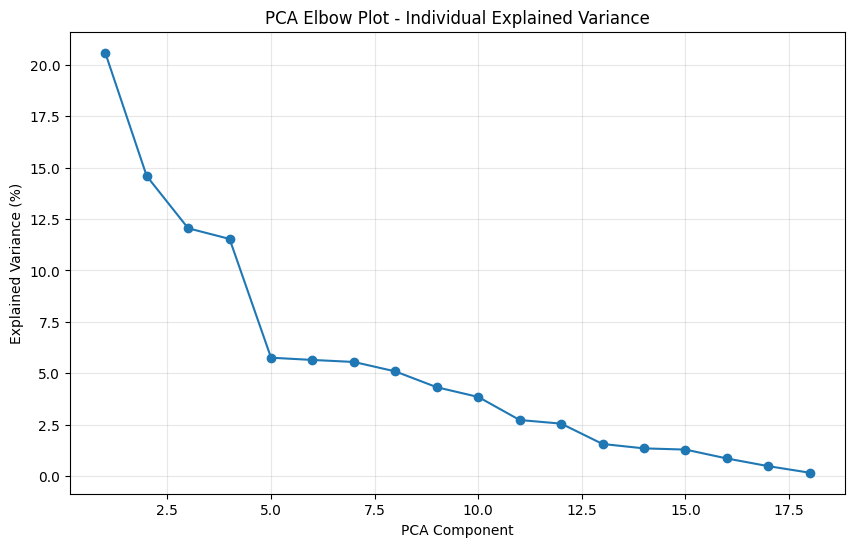

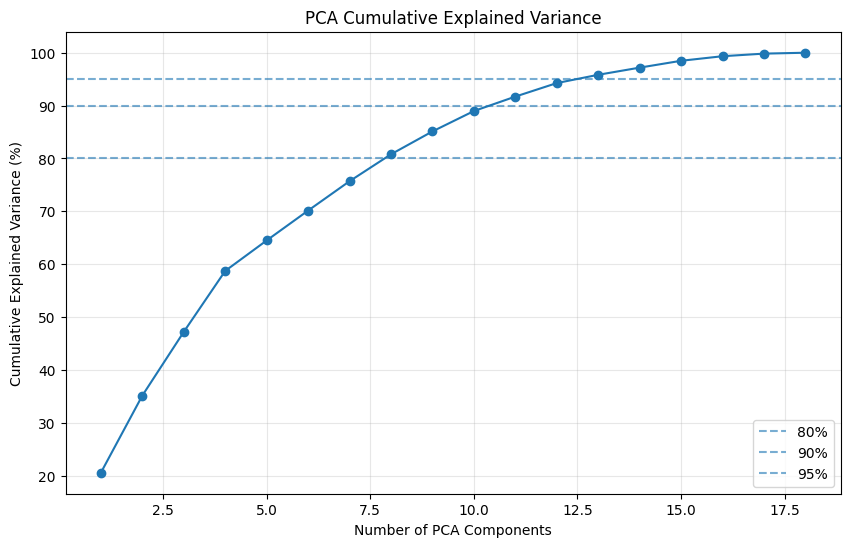


PCA variance summary:
    component  explained_variance_pct  cumulative_variance_pct
0           1               20.576485                20.576485
1           2               14.584414                35.160899
2           3               12.048557                47.209456
3           4               11.528993                58.738449
4           5                5.759111                64.497560
5           6                5.650430                70.147989
6           7                5.552227                75.700217
7           8                5.092904                80.793121
8           9                4.324363                85.117484
9          10                3.852919                88.970403
10         11                2.731884                91.702286
11         12                2.556510                94.258796
12         13                1.567505                95.826301
13         14                1.354085                97.180386
14         15                1.2

In [40]:
elbow_df, evaluation_df, pca_df, pca, scaler = plot_pca_elbow_and_evaluate(
    signal_df,
    feature_cols=feature_cols,
    label_col="label",
    sample_size=20000
)

# **Conclusion**

*   Class 0 and Class 1 occupy almost the same region of feature space.
*   No obvious decision boundary.
*   No obvious clusters.


Hence, there is no pattern to model the Target variable